# Yield Simulator for W2W Hybrid Bonding
#### Author: Zhichao Chen
#### Date: Aug 25, 2025
#### Description: YAP+ (pad-layout-aware yield analysis)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from utils.util import *
import time
import matplotlib.pyplot as plt
from assembly_yield_simulator import Assembly_Yield_Simulator

redundant_net_to_bumpids: {'VDD': {0, 32770, 32771, 4, 6, 32774, 32775, 32778, 11, 32779, 32781, 32782, 16, 32784, 32786, 19, 32787, 21, 22, 23, 32790, 25, 32793, 32795, 28, 29, 30, 31, 32800, 34, 35, 32803, 38, 39, 32806, 32808, 42, 43, 32809, 32814, 32815, 48, 32819, 52, 54, 32822, 32825, 32827, 32828, 32830, 63, 32831, 65, 32832, 67, 70, 32839, 73, 32841, 32842, 32843, 32845, 82, 32850, 84, 85, 32854, 32855, 90, 32858, 32860, 94, 95, 96, 32862, 98, 99, 32863, 101, 32864, 32868, 32869, 32873, 32874, 32876, 32877, 113, 32882, 115, 32884, 117, 119, 120, 122, 123, 32891, 126, 127, 32894, 32896, 32899, 133, 32902, 135, 136, 137, 138, 139, 32903, 32908, 142, 145, 32913, 147, 148, 32916, 32917, 151, 155, 156, 32924, 32925, 32926, 32932, 166, 32934, 168, 32936, 170, 32938, 174, 32943, 177, 32945, 181, 183, 32952, 186, 187, 189, 32958, 32959, 199, 32968, 203, 32973, 206, 32976, 209, 210, 32977, 212, 213, 32978, 215, 32979, 32981, 218, 32983, 32986, 32987, 222, 32991, 32992, 227, 32998, 231, 

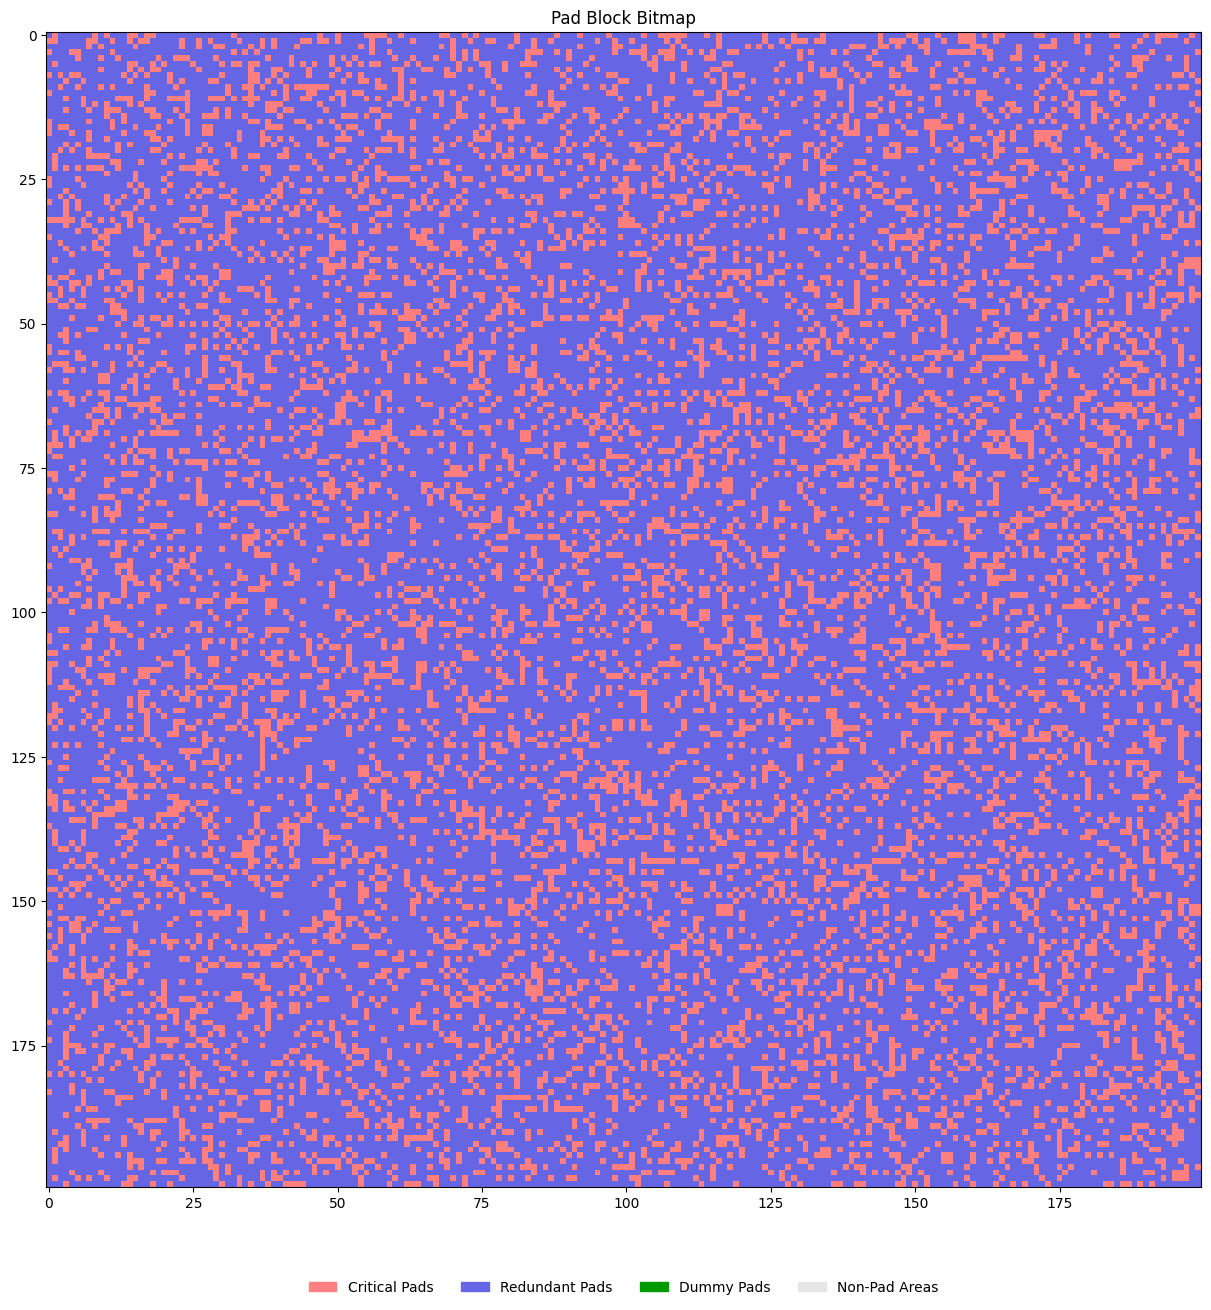

In [23]:
# Load configuration
cfg = load_modeling_config(path='configs/random_10x10_50.yaml', 
                     mode='w2w_simulation',
                     debug=False)

# Generate pad bitmap collection
pad_bitmap_collection = convert_3dblox_to_pad_bitmap(cfg=cfg,
                                                     blox_bmap_path='input/' + cfg.DESIGN + '.bmap',
                                                     criticality_path='input/' + cfg.DESIGN + '_criticality.txt',
                                                     pad_arrange_pattern=cfg.PAD_ARRANGE_PATTERN)
start_time = time.time()
# Update above parameters in the configuration
update_config_items(cfg=cfg, mode='w2w_simulation')

assembly_yield, single_config_yield_list = Assembly_Yield_Simulator(
    cfg=cfg,
    pad_bitmap_collection=pad_bitmap_collection,                                    
)                                                       
print("Assembly Yield: {:.4f}".format(assembly_yield))
print("Total time taken: {:.2f} seconds".format(time.time() - start_time))

In [ ]:
np.save('sim_df_yield_list_pd_-10_-8d1_size_1e4_300params_200dim.npy', assembly_yield_list)

[0.6678631229177094,
 0.6668266431792271,
 0.6681962771193644,
 0.663606152563229,
 0.6633100154950913,
 0.6654570092390901,
 0.6638652724978494,
 0.6618663472879195,
 0.6645685980346768,
 0.6621624843560574]

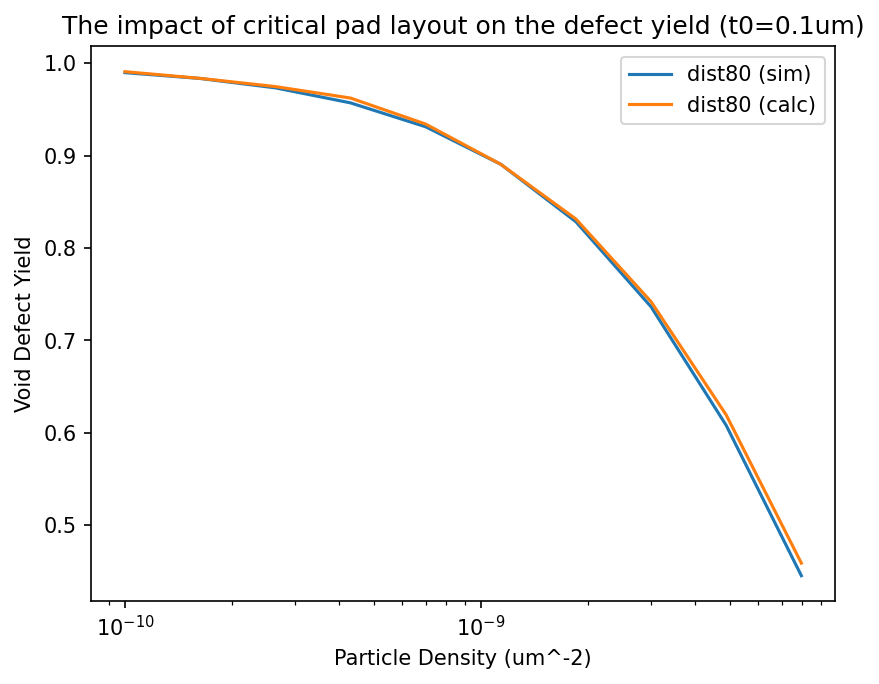

In [ ]:
particle_density_list = np.logspace(-10, -8.1, 10)
redundant_2copy_yield_dist80_critical_simulate = [0.9898717150057933,
 0.9835840362219836,
 0.9734456446297147,
 0.9571835960590951,
 0.9313200288008368,
 0.8907502895065961,
 0.8285237929258553,
 0.7364898897985741,
 0.608160052042089,
 0.44547230967179824]
redundant_2copy_yield_dist80_critical_calculate = [0.9909259259259258,
 0.9837037037037037,
 0.9748148148148147,
 0.9624074074074075,
 0.9342592592592593,
 0.8907407407407408,
 0.8314814814814815,
 0.742037037037037,
 0.6194444444444445,
 0.4590740740740741]
redundant_2copy_yield_dist80_critical_simulate = np.array(redundant_2copy_yield_dist80_critical_simulate)
redundant_2copy_yield_dist80_critical_calculate = np.array(redundant_2copy_yield_dist80_critical_calculate)
# plot the calculated yield vs. the simulated yield
plt.figure(dpi=150)
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_simulate, label='dist80 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_calculate, label='dist80 (calc)')
plt.xscale('log')
plt.xlabel('Particle Density (um^-2)')
plt.ylabel('Void Defect Yield')
plt.title('The impact of critical pad layout on the defect yield (t0=0.1um)')
plt.legend()
plt.show()


### Y_sim v.s. Y_calc -> pad_block_size = 200 um

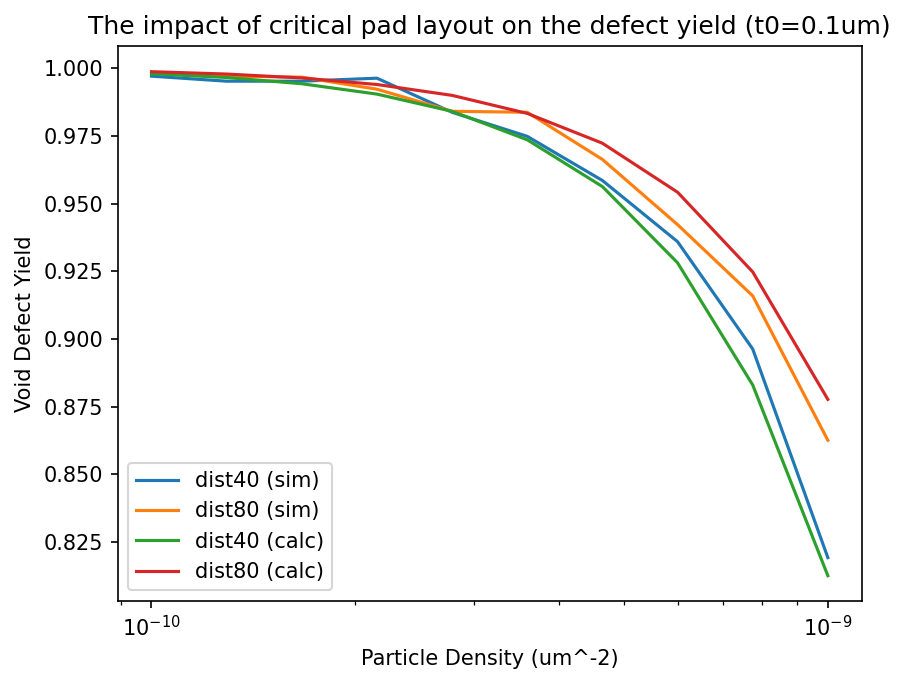

In [ ]:
particle_density_list = np.logspace(-10, -9, 10)
redundant_2copy_yield_dist40_critical_simulate = [0.9970370370370372,
 0.9951851851851853,
 0.9951851851851851,
 0.9962962962962963,
 0.9837037037037037,
 0.9748148148148148,
 0.9585185185185185,
 0.9359259259259259,
 0.8962962962962964,
 0.8192592592592594]
redundant_2copy_yield_dist80_critical_simulate = [0.9981481481481481,
 0.9970370370370369,
 0.9966666666666667,
 0.9922222222222221,
 0.984074074074074,
 0.9837037037037037,
 0.9662962962962963,
 0.9422222222222223,
 0.915925925925926,
 0.8625925925925927]
redundant_2copy_yield_dist40_critical_calculate = [0.9979268444252244,
 0.9965441635793376,
 0.9942419748401686,
 0.9904135217896465,
 0.9840600547330917,
 0.973552401638131,
 0.9562736659018274,
 0.928130727641162,
 0.8830164770269793,
 0.8125882513306562]
redundant_2copy_yield_dist80_critical_calculate = [0.9986962328735638,
 0.9978261326761374,
 0.996376404681686,
 0.9939627983089665,
 0.989949663997837,
 0.9832913772390017,
 0.9722841928175462,
 0.9541966166159586,
 0.9247704073078236,
 0.8776900402331577]
# redundant_2copy_yield_dist20_critical_simulate = np.array(redundant_2copy_yield_dist20_critical_simulate)
redundant_2copy_yield_dist40_critical_simulate = np.array(redundant_2copy_yield_dist40_critical_simulate)
redundant_2copy_yield_dist80_critical_simulate = np.array(redundant_2copy_yield_dist80_critical_simulate)
# redundant_2copy_yield_dist20_critical_calculate = np.array(redundant_2copy_yield_dist20_critical_calculate)
redundant_2copy_yield_dist40_critical_calculate = np.array(redundant_2copy_yield_dist40_critical_calculate)
redundant_2copy_yield_dist80_critical_calculate = np.array(redundant_2copy_yield_dist80_critical_calculate)
# redundant_2copy_yield_dist120_critical_calculate = np.array(redundant_2copy_yield_dist120_critical_calculate)
# plot the calculated yield vs. the simulated yield
plt.figure(dpi=150)
# plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_simulate, label='dist20 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_simulate, label='dist40 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_simulate, label='dist80 (sim)')
# plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_simulate, label='dist120 (sim)')
# plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_calculate, label='dist20 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_calculate, label='dist40 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_calculate, label='dist80 (calc)')
# plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_calculate, label='dist120 (calc)')
plt.xscale('log')
plt.xlabel('Particle Density (um^-2)')
plt.ylabel('Void Defect Yield')
plt.title('The impact of critical pad layout on the defect yield (t0=0.1um)')
plt.legend()
plt.show()


### Y_sim v.s. Y_calc -> pad_block_size = 400 um

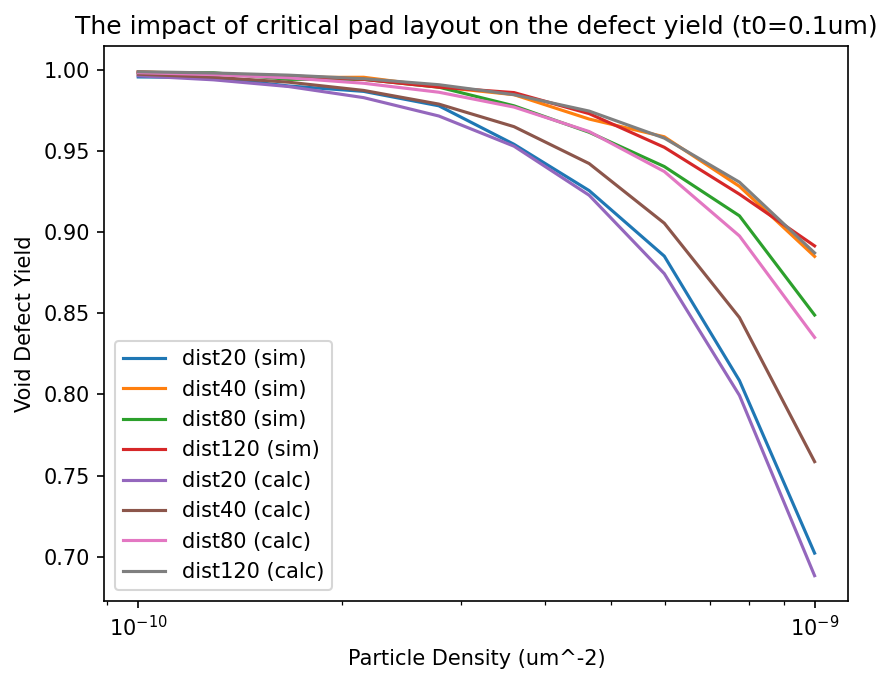

In [ ]:
particle_density_list = np.logspace(-10, -9, 10)
redundant_2copy_yield_dist20_critical_simulate = [0.9955555555555555,
 0.9951851851851853,
 0.9899999999999999,
 0.9866666666666666,
 0.9777777777777776,
 0.9540740740740741,
 0.9255555555555555,
 0.8851851851851851,
 0.8085185185185185,
 0.7022222222222221]
redundant_2copy_yield_dist40_critical_simulate = [0.9987037037037038,
 0.9974074074074075,
 0.9951851851851851,
 0.9953703703703702,
 0.9894444444444443,
 0.9846296296296295,
 0.9696296296296296,
 0.9587037037037037,
 0.9281481481481482,
 0.885]
redundant_2copy_yield_dist80_critical_simulate = [0.9981481481481481,
 0.9981481481481481,
 0.9940740740740741,
 0.9940740740740741,
 0.9892592592592593,
 0.9777777777777776,
 0.9614814814814816,
 0.9403703703703703,
 0.9100000000000001,
 0.8488888888888889]
redundant_2copy_yield_dist120_critical_simulate = [0.9985185185185184,
 0.9974074074074075,
 0.9962962962962963,
 0.994074074074074,
 0.9892592592592593,
 0.9859259259259259,
 0.9729629629629629,
 0.9522222222222222,
 0.9233333333333332,
 0.8914814814814814]
redundant_2copy_yield_dist20_critical_calculate = [0.9962719706268514,
 0.9937890198858643,
 0.9896609713716195,
 0.9828130944857648,
 0.9714954283081776,
 0.9529057049927289,
 0.922684387438409,
 0.8743899907397026,
 0.7993893819204969,
 0.688321275800331]
redundant_2copy_yield_dist40_critical_calculate = [0.9972405468188179,
 0.9954011990317654,
 0.9923405284682401,
 0.9872559504564457,
 0.978832272329579,
 0.964940370269552,
 0.9422046349936692,
 0.9054649732314973,
 0.8473397577488223,
 0.7585650298472465]
redundant_2copy_yield_dist80_critical_calculate = [0.9981998313899894,
 0.9969989438960519,
 0.9949989569652272,
 0.9916717016993505,
 0.9861462465825459,
 0.9769976582449255,
 0.9619253718696205,
 0.9372989418683182,
 0.8976145590805416,
 0.8351206395453719]
redundant_2copy_yield_dist120_critical_calculate = [0.9988033526970544,
 0.9980046700297118,
 0.996673808015505,
 0.9944577445723927,
 0.9907720874491673,
 0.9846544132303667,
 0.9745334626951304,
 0.9578816704657115,
 0.9307355630722097,
 0.8871542724446094]
redundant_2copy_yield_dist20_critical_simulate = np.array(redundant_2copy_yield_dist20_critical_simulate)
redundant_2copy_yield_dist40_critical_simulate = np.array(redundant_2copy_yield_dist40_critical_simulate)
redundant_2copy_yield_dist80_critical_simulate = np.array(redundant_2copy_yield_dist80_critical_simulate)
redundant_2copy_yield_dist20_critical_calculate = np.array(redundant_2copy_yield_dist20_critical_calculate)
redundant_2copy_yield_dist40_critical_calculate = np.array(redundant_2copy_yield_dist40_critical_calculate)
redundant_2copy_yield_dist80_critical_calculate = np.array(redundant_2copy_yield_dist80_critical_calculate)
redundant_2copy_yield_dist120_critical_calculate = np.array(redundant_2copy_yield_dist120_critical_calculate)
# plot the calculated yield vs. the simulated yield
plt.figure(dpi=150)
plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_simulate, label='dist20 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_simulate, label='dist40 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_simulate, label='dist80 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_simulate, label='dist120 (sim)')
plt.plot(particle_density_list, redundant_2copy_yield_dist20_critical_calculate, label='dist20 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist40_critical_calculate, label='dist40 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist80_critical_calculate, label='dist80 (calc)')
plt.plot(particle_density_list, redundant_2copy_yield_dist120_critical_calculate, label='dist120 (calc)')
plt.xscale('log')
plt.xlabel('Particle Density (um^-2)')
plt.ylabel('Void Defect Yield')
plt.title('The impact of critical pad layout on the defect yield (t0=0.1um)')
plt.legend()
plt.show()